In [3]:
import os, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import xgboost as xgb
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks, mixed_precision
from sklearn.linear_model  import LinearRegression, LogisticRegression
from sklearn.ensemble      import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics       import (accuracy_score, precision_score, recall_score,
                                   f1_score, roc_auc_score,
                                   confusion_matrix, ConfusionMatrixDisplay)

warnings.filterwarnings("ignore")


DATA_PATH   = "/content/drive/MyDrive/Bioinformatics /Enhancers_Projects/enhancer_kmer_features.csv"  # path to your CSV in Colab
SAVE_DIR    = "/content/drive/MyDrive/Bioinformatics /Enhancers_Projects/models"            # where models + plots are saved
RANDOM_SEED = 42
BATCH_SIZE  = 4096   # number of rows processed at once by the neural network
DL_EPOCHS   = 50     # maximum training epochs for the neural network

os.makedirs(SAVE_DIR, exist_ok=True)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

print("✔ Imports complete")


In [4]:
# Allow TensorFlow to grow GPU memory as needed (avoids out-of-memory crashes)
# mixed_float16 uses 16-bit numbers during training to save GPU RAM
gpus = tf.config.list_physical_devices("GPU")

if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    mixed_precision.set_global_policy("mixed_float16")
    GPU_AVAILABLE = True
    print(f"[GPU] {len(gpus)} GPU(s) detected — mixed_float16 enabled")
else:
    GPU_AVAILABLE = False
    print("[GPU] No GPU detected — running on CPU")


[GPU] 1 GPU(s) detected — mixed_float16 enabled


In [5]:
# All 84 kmer frequency columns (1-mer, 2-mer, 3-mer)
FEATURE_COLS = [f"kmer_{k}" for k in [
    "A", "C", "G", "T",
    "AA","AC","AG","AT","CA","CC","CG","CT","GA","GC","GG","GT",
    "TA","TC","TG","TT",
    "AAA","AAC","AAG","AAT","ACA","ACC","ACG","ACT","AGA","AGC","AGG","AGT",
    "ATA","ATC","ATG","ATT","CAA","CAC","CAG","CAT","CCA","CCC","CCG","CCT",
    "CGA","CGC","CGG","CGT","CTA","CTC","CTG","CTT","GAA","GAC","GAG","GAT",
    "GCA","GCC","GCG","GCT","GGA","GGC","GGG","GGT","GTA","GTC","GTG","GTT",
    "TAA","TAC","TAG","TAT","TCA","TCC","TCG","TCT","TGA","TGC","TGG","TGT",
    "TTA","TTC","TTG","TTT",
]]
TARGET_COL = "label"

print(f"✔ {len(FEATURE_COLS)} feature columns defined")


✔ 84 feature columns defined


In [6]:
print(f"[Data] Loading {DATA_PATH} ...")
t0 = time.time()

# Read only the columns we need; use float32 to halve memory vs float64.
# NOTE: dtype must be a dict, not a single value — the 'split' column holds
# strings ("train"/"val"/"test"), so forcing float32 on every column would
# crash the CSV load (and 'split' isn't even in FEATURE_COLS/TARGET_COL below).
dtype_map = {col: np.float32 for col in FEATURE_COLS}
dtype_map[TARGET_COL] = np.float32

df = pd.read_csv(
    DATA_PATH,
    dtype=dtype_map,
    usecols=lambda col: col in FEATURE_COLS + [TARGET_COL, "split"]
)
print(f"[Data] Loaded {len(df):,} rows in {time.time() - t0:.1f}s")

# Fix label dtype
df[TARGET_COL] = df[TARGET_COL].astype(np.int8)

# Fill any missing feature values with the column median
missing = df[FEATURE_COLS].isnull().sum().sum()
if missing:
    print(f"[Data] Imputing {missing} missing values with column medians")
    for col in FEATURE_COLS:
        df[col] = df[col].fillna(df[col].median())

# Use the pre-built split column; fall back to a 70/15/15 stratified split
if "split" in df.columns:
    train_df = df[df["split"] == "train"].drop(columns=["split"])
    val_df   = df[df["split"] == "val"].drop(columns=["split"])
    test_df  = df[df["split"] == "test"].drop(columns=["split"])
else:
    from sklearn.model_selection import train_test_split
    train_df, tmp = train_test_split(df, test_size=0.30,
                                     random_state=RANDOM_SEED, stratify=df[TARGET_COL])
    val_df, test_df = train_test_split(tmp, test_size=0.50,
                                       random_state=RANDOM_SEED, stratify=tmp[TARGET_COL])

# Print split sizes and class balance
for name, d in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
    print(f"  {name:5s}: {len(d):>8,} rows | pos_rate={d[TARGET_COL].mean():.3f}")


[Data] Loading /content/drive/MyDrive/Bioinformatics /Enhancers_Projects/enhancer_kmer_features.csv ...
[Data] Loaded 1,225,976 rows in 46.6s
  Train:  857,474 rows | pos_rate=0.528
  Val  :  245,529 rows | pos_rate=0.526
  Test :  122,973 rows | pos_rate=0.526


In [7]:
# StandardScaler: subtract mean, divide by std — keeps all features on the same scale
# Fit only on train; apply the same transform to val and test
scaler = StandardScaler()

X_tr   = scaler.fit_transform(train_df[FEATURE_COLS].values)
X_val  = scaler.transform(val_df[FEATURE_COLS].values)
X_test = scaler.transform(test_df[FEATURE_COLS].values)

y_tr   = train_df[TARGET_COL].values
y_val  = val_df[TARGET_COL].values
y_test = test_df[TARGET_COL].values

# Save the scaler so we can apply it at inference time
joblib.dump(scaler, f"{SAVE_DIR}/scaler.joblib")

print("✔ Data ready | scaler saved")


✔ Data ready | scaler saved


In [8]:
def compute_metrics(name, y_true, y_pred, y_prob=None):
    """Calculate and print accuracy, precision, recall, F1, and AUC-ROC."""
    results = {
        "model"    : name,
        "accuracy" : accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall"   : recall_score(y_true, y_pred, zero_division=0),
        "f1"       : f1_score(y_true, y_pred, zero_division=0),
        "auc_roc"  : roc_auc_score(y_true, y_prob) if y_prob is not None else float("nan"),
    }
    print(f"  {name:<22}  Acc={results['accuracy']:.4f}  "
          f"F1={results['f1']:.4f}  AUC={results['auc_roc']:.4f}")
    return results


In [9]:
#  Linear Regression 
# Not a true classifier — we clamp its output to [0, 1] and threshold at 0.5.
# Useful as a naive baseline.
print("[Model] Linear Regression ...")
t0 = time.time()

lr_model = LinearRegression()
lr_model.fit(X_tr, y_tr)

raw_preds = lr_model.predict(X_val)
lr_prob   = np.clip(raw_preds, 0, 1)        # keep values in valid range
lr_pred   = (lr_prob >= 0.5).astype(int)    # convert to 0 / 1
lr_m      = compute_metrics("LinearRegression", y_val, lr_pred, lr_prob)

joblib.dump(lr_model, f"{SAVE_DIR}/linear_regression.joblib")
print(f"  Done in {time.time() - t0:.1f}s")


#  Logistic Regression 
# Classic linear classifier. 'saga' solver scales well to large datasets.
print("\n[Model] Logistic Regression ...")
t0 = time.time()

log_model = LogisticRegression(
    solver="saga",          # fast solver for large data
    max_iter=500,
    C=1.0,                  # regularisation strength (higher = less penalty)
    random_state=RANDOM_SEED,
    n_jobs=-1,              
)
log_model.fit(X_tr, y_tr)

log_prob = log_model.predict_proba(X_val)[:, 1]  # probability of class 1
log_pred = log_model.predict(X_val)
log_m    = compute_metrics("LogisticRegression", y_val, log_pred, log_prob)

joblib.dump(log_model, f"{SAVE_DIR}/logistic_regression.joblib")
print(f"  Done in {time.time() - t0:.1f}s")


[Model] Linear Regression ...
  LinearRegression        Acc=0.6477  F1=0.6672  AUC=0.7079
  Done in 4.3s

[Model] Logistic Regression ...
  LogisticRegression      Acc=0.6470  F1=0.6673  AUC=0.7075
  Done in 49.3s


In [10]:
#  Random Forest 

print("[Model] Random Forest ...")
t0 = time.time()

rf_model = RandomForestClassifier(
    n_estimators=200,       # number of trees
    max_depth=20,           # max tree depth — prevents overfitting
    min_samples_leaf=10,    # minimum samples needed at a leaf node
    class_weight="balanced",
    n_jobs=-1,
    random_state=RANDOM_SEED,
)
rf_model.fit(X_tr, y_tr)

rf_prob = rf_model.predict_proba(X_val)[:, 1]
rf_pred = rf_model.predict(X_val)
rf_m    = compute_metrics("RandomForest", y_val, rf_pred, rf_prob)

joblib.dump(rf_model, f"{SAVE_DIR}/random_forest.joblib")
print(f"  Done in {time.time() - t0:.1f}s")


[Model] Random Forest ...
  RandomForest            Acc=0.9310  F1=0.9302  AUC=0.9956
  Done in 590.7s


In [11]:
#  XGBoost 
print("[Model] XGBoost ...")
t0 = time.time()

# Handle class imbalance: weight positive samples higher if they are fewer
neg_count = (y_tr == 0).sum()
pos_count = (y_tr == 1).sum()
scale_pos = neg_count / max(pos_count, 1)

xgb_model = xgb.XGBClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos,
    device="cuda" if GPU_AVAILABLE else "cpu",
    tree_method="hist",
    eval_metric="auc",
    early_stopping_rounds=30,
    random_state=RANDOM_SEED,
    verbosity=0,
)
xgb_model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)

xgb_prob = xgb_model.predict_proba(X_val)[:, 1]
xgb_pred = xgb_model.predict(X_val)
xgb_m    = compute_metrics("XGBoost", y_val, xgb_pred, xgb_prob)

xgb_model.save_model(f"{SAVE_DIR}/xgboost.json")
print(f"  Best iteration: {xgb_model.best_iteration} | Done in {time.time() - t0:.1f}s")


[Model] XGBoost ...
  XGBoost                 Acc=0.9653  F1=0.9666  AUC=0.9962
  Best iteration: 999 | Done in 33.0s


In [12]:
#  Fully-Connected Neural Network 
# Architecture: Input(84) → Dense(512) → Dense(256) → Dense(128) → Dense(64) → Output(1)
# BatchNorm stabilises training; Dropout randomly zeros out neurons to prevent overfitting.
# The output layer uses float32 (not float16) for numerical stability with mixed precision.

def build_neural_network(num_features):
    """Build and compile a fully-connected binary classification network."""
    inputs = layers.Input(shape=(num_features,), name="features")

    x = layers.Dense(512, activation="relu")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Dense(256, activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Dense(128, activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)

    x = layers.Dense(64, activation="relu")(x)

    # float32 output for numerical stability under mixed_float16 policy
    output = layers.Dense(1, dtype="float32")(x)
    output = layers.Activation("sigmoid", dtype="float32", name="prob")(output)

    model = keras.Model(inputs=inputs, outputs=output, name="FCNN")
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=["accuracy", keras.metrics.AUC(name="auc")],
    )
    return model


print("[Model] Fully-Connected Neural Network ...")
t0 = time.time()

nn_model = build_neural_network(X_tr.shape[1])
nn_model.summary()

# Weight the minority class higher so the model does not ignore it
class_weight = {0: 1.0, 1: (y_tr == 0).sum() / max((y_tr == 1).sum(), 1)}

training_callbacks = [
    # Save the best model checkpoint based on validation AUC
    callbacks.ModelCheckpoint(
        f"{SAVE_DIR}/fcnn_best.keras", monitor="val_auc",
        mode="max", save_best_only=True, verbose=0
    ),
    # Stop early if validation AUC does not improve for 8 epochs
    callbacks.EarlyStopping(
        monitor="val_auc", patience=8, mode="max",
        restore_best_weights=True, verbose=1
    ),
    # Halve the learning rate when validation loss plateaus
    callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=4, min_lr=1e-6, verbose=0
    ),
]

nn_hist = nn_model.fit(
    X_tr.astype(np.float32), y_tr,
    validation_data=(X_val.astype(np.float32), y_val),
    epochs=DL_EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weight,
    callbacks=training_callbacks,
    verbose=1,
)

nn_prob = nn_model.predict(X_val.astype(np.float32), batch_size=BATCH_SIZE, verbose=0).ravel()
nn_pred = (nn_prob >= 0.5).astype(int)
nn_m    = compute_metrics("FCNN", y_val, nn_pred, nn_prob)

print(f"  Done in {time.time() - t0:.1f}s")


[Model] Fully-Connected Neural Network ...


Model: "FCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ features (InputLayer)           │ (None, 84)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │        43,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ prob (Activation)               │ (None, 1)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 219,649 (858.00 KB)

 Trainable params: 217,857 (851.00 KB)

 Non-trainable params: 1,792 (7.00 KB)

Epoch 1/50
210/210 ━━━━━━━━━━━━━━━━━━━━ 22s 55ms/step - accuracy: 0.7366 - auc: 0.8217 - loss: 0.4599 - val_accuracy: 0.7782 - val_auc: 0.8712 - val_loss: 0.4345 - learning_rate: 0.0010
Epoch 2/50
210/210 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7779 - auc: 0.8719 - loss: 0.4040 - val_accuracy: 0.8290 - val_auc: 0.9190 - val_loss: 0.3666 - learning_rate: 0.0010
Epoch 3/50
210/210 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8084 - auc: 0.9012 - loss: 0.3638 - val_accuracy: 0.8660 - val_auc: 0.9467 - val_loss: 0.3077 - learning_rate: 0.0010
Epoch 4/50
210/210 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.8331 - auc: 0.9215 - loss: 0.3296 - val_accuracy: 0.8946 - val_auc: 0.9636 - val_loss: 0.2558 - learning_rate: 0.0010
Epoch 5/50
210/210 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.8516 - auc: 0.9354 - loss: 0.3017 - val_accuracy: 0.9154 - val_auc: 0.9747 - val_loss: 0.2175 - learning_rate: 0.0010
Epoch 6/50
210/210 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8662 - auc

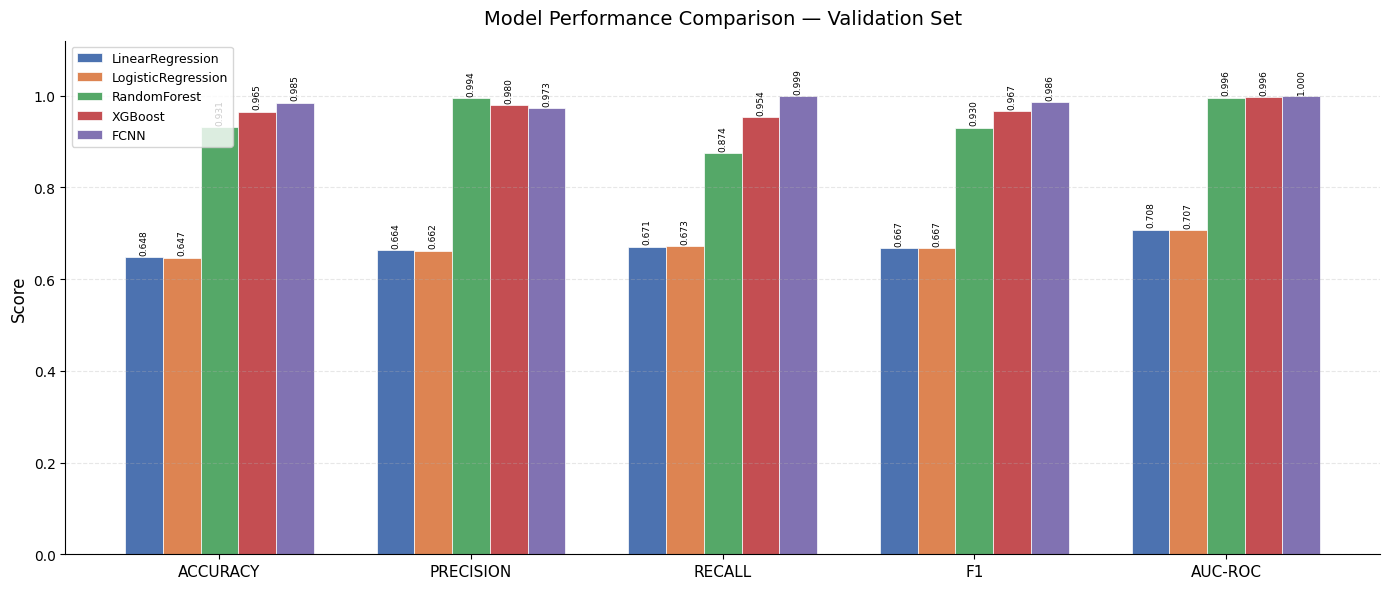

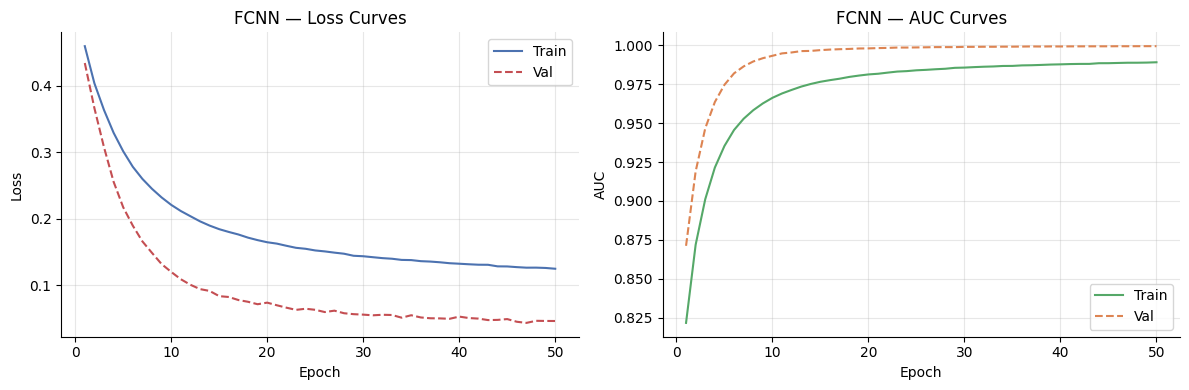

In [13]:
# Collect all validation results into one list
val_results  = [lr_m, log_m, rf_m, xgb_m, nn_m]
METRIC_LABELS = ["accuracy", "precision", "recall", "f1", "auc_roc"]

MODEL_COLORS = {
    "LinearRegression"  : "#4C72B0",
    "LogisticRegression": "#DD8452",
    "RandomForest"      : "#55A868",
    "XGBoost"           : "#C44E52",
    "FCNN"              : "#8172B2",
}

df_res  = pd.DataFrame(val_results).set_index("model")
model_names = df_res.index.tolist()
x     = np.arange(len(METRIC_LABELS))
width = 0.15  # width of each bar

fig, ax = plt.subplots(figsize=(14, 6))

for i, model_name in enumerate(model_names):
    values = [df_res.loc[model_name, m] for m in METRIC_LABELS]
    bars = ax.bar(
        x + i * width, values, width,
        label=model_name,
        color=MODEL_COLORS.get(model_name, "#888"),
        edgecolor="white", linewidth=0.5
    )
    # Print the score on top of each bar
    for bar, v in zip(bars, values):
        if not np.isnan(v):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.005, f"{v:.3f}",
                    ha="center", va="bottom", fontsize=6.5, rotation=90)

ax.set_xticks(x + width * (len(model_names) - 1) / 2)
ax.set_xticklabels([m.upper().replace("_", "-") for m in METRIC_LABELS], fontsize=11)
ax.set_ylim(0, 1.12)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("Model Performance Comparison — Validation Set", fontsize=14, pad=12)
ax.legend(fontsize=9, framealpha=0.8)
ax.grid(axis="y", alpha=0.3, linestyle="--")
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(f"{SAVE_DIR}/metric_comparison.png", dpi=200, bbox_inches="tight")
plt.show()


#  FCNN learning curves 
h = nn_hist.history
epochs = range(1, len(h["loss"]) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs, h["loss"],     label="Train", color="#4C72B0")
ax1.plot(epochs, h["val_loss"], label="Val",   color="#C44E52", linestyle="--")
ax1.set(xlabel="Epoch", ylabel="Loss", title="FCNN — Loss Curves")
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(epochs, h["auc"],     label="Train", color="#55A868")
ax2.plot(epochs, h["val_auc"], label="Val",   color="#DD8452", linestyle="--")
ax2.set(xlabel="Epoch", ylabel="AUC", title="FCNN — AUC Curves")
ax2.legend()
ax2.grid(alpha=0.3)

for ax in (ax1, ax2):
    ax.spines[["top", "right"]].set_visible(False)

fig.tight_layout()
fig.savefig(f"{SAVE_DIR}/fcnn_learning_curves.png", dpi=200, bbox_inches="tight")
plt.show()


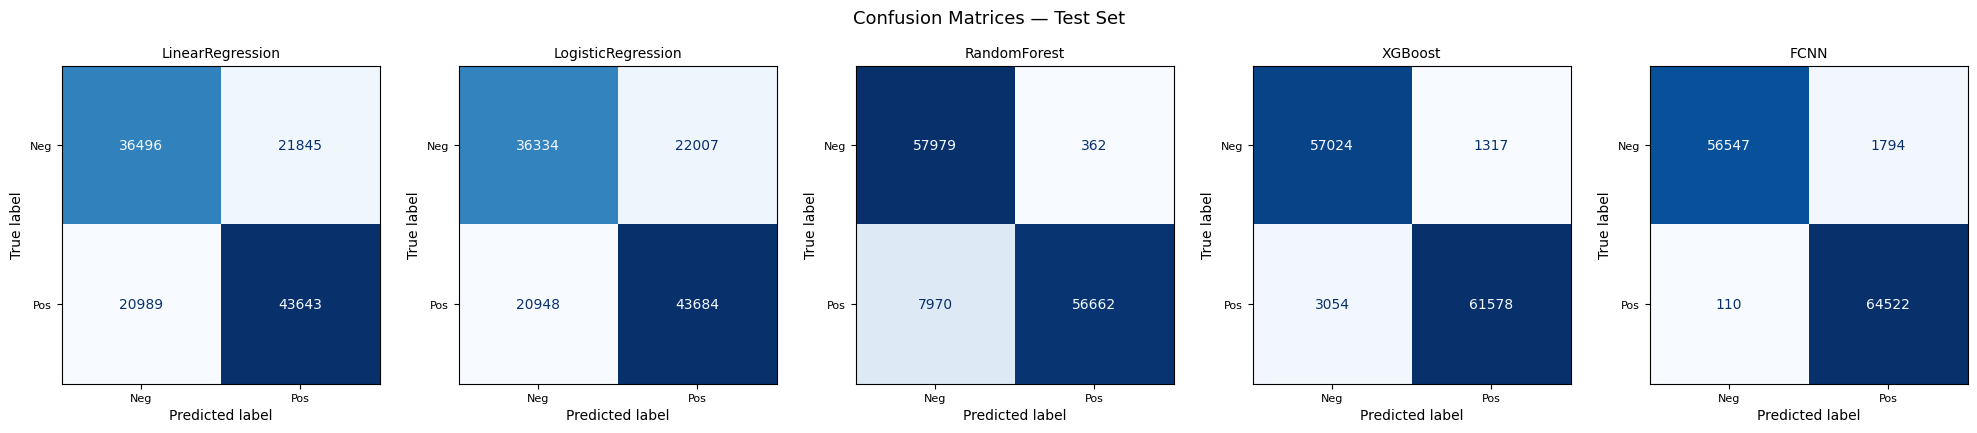

In [14]:
# Build a dict of all trained models so we can loop over them
models_dict = {
    "LinearRegression"  : lr_model,
    "LogisticRegression": log_model,
    "RandomForest"      : rf_model,
    "XGBoost"           : xgb_model,
    "FCNN"              : nn_model,
}

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for ax, (model_name, model) in zip(axes, models_dict.items()):
    # Predict on the test set (each model needs its own prediction approach)
    if model_name == "LinearRegression":
        raw  = model.predict(X_test)
        pred = (np.clip(raw, 0, 1) >= 0.5).astype(int)
    elif model_name == "FCNN":
        prob = model.predict(X_test.astype(np.float32), batch_size=BATCH_SIZE, verbose=0).ravel()
        pred = (prob >= 0.5).astype(int)
    else:
        pred = model.predict(X_test)

    cm = confusion_matrix(y_test, pred)
    ConfusionMatrixDisplay(cm, display_labels=["Neg", "Pos"]).plot(
        ax=ax, colorbar=False, cmap="Blues"
    )
    ax.set_title(model_name, fontsize=10, pad=6)
    ax.tick_params(labelsize=8)

fig.suptitle("Confusion Matrices — Test Set", fontsize=13, y=1.02)
fig.tight_layout()
fig.savefig(f"{SAVE_DIR}/confusion_matrices.png", dpi=200, bbox_inches="tight")
plt.show()


In [15]:
#  Pick the best model based on validation F1 score 
df_val    = pd.DataFrame(val_results)
best_row  = df_val.loc[df_val["f1"].idxmax()]
best_name = best_row["model"]
best_model = models_dict[best_name]

print("=" * 60)
print(f"  Best model (val F1): {best_name}")
print(f"  Val  — F1={best_row['f1']:.4f}  AUC={best_row['auc_roc']:.4f}")
print("=" * 60)

#  Final evaluation on the held-out test set 
def predict_test(model_name, model):
    """Get predictions and probabilities for the test set."""
    if model_name == "LinearRegression":
        prob = np.clip(model.predict(X_test), 0, 1)
        return (prob >= 0.5).astype(int), prob
    elif model_name == "FCNN":
        prob = model.predict(X_test.astype(np.float32), batch_size=BATCH_SIZE, verbose=0).ravel()
        return (prob >= 0.5).astype(int), prob
    else:
        return model.predict(X_test), model.predict_proba(X_test)[:, 1]

test_pred, test_prob = predict_test(best_name, best_model)
test_m = compute_metrics(f"{best_name} [TEST]", y_test, test_pred, test_prob)

#  Save the best model 
save_path = f"{SAVE_DIR}/best_model"
if best_name == "FCNN":
    best_model.save(save_path + ".keras")
    print(f"  Saved → {save_path}.keras")
elif best_name == "XGBoost":
    best_model.save_model(save_path + ".json")
    print(f"  Saved → {save_path}.json")
else:
    joblib.dump(best_model, save_path + ".joblib")
    print(f"  Saved → {save_path}.joblib")

# Final summary table 
print("\n" + "─" * 60)
print("  VALIDATION METRICS SUMMARY")
summary = pd.DataFrame(val_results).set_index("model")
print(summary[["accuracy", "precision", "recall", "f1", "auc_roc"]]
      .to_string(float_format="{:.4f}".format))
print("─" * 60)
print(f"  ✔  Winner : {best_name}")
print(f"     Test   — Acc={test_m['accuracy']:.4f}  "
      f"F1={test_m['f1']:.4f}  AUC={test_m['auc_roc']:.4f}")
print(f"  All artefacts saved to: {SAVE_DIR}/")
print("─" * 60)


  Best model (val F1): FCNN
  Val  — F1=0.9857  AUC=0.9995
  FCNN [TEST]             Acc=0.9845  F1=0.9855  AUC=0.9994
  Saved → /content/drive/MyDrive/Bioinformatics /Enhancers_Projects/models/best_model.keras

────────────────────────────────────────────────────────────
  VALIDATION METRICS SUMMARY
                    accuracy  precision  recall     f1  auc_roc
model                                                          
LinearRegression      0.6477     0.6636  0.6709 0.6672   0.7079
LogisticRegression    0.6470     0.6622  0.6725 0.6673   0.7075
RandomForest          0.9310     0.9943  0.8740 0.9302   0.9956
XGBoost               0.9653     0.9800  0.9536 0.9666   0.9962
FCNN                  0.9848     0.9731  0.9987 0.9857   0.9995
────────────────────────────────────────────────────────────
  ✔  Winner : FCNN
     Test   — Acc=0.9845  F1=0.9855  AUC=0.9994
  All artefacts saved to: /content/drive/MyDrive/Bioinformatics /Enhancers_Projects/models/
──────────────────────────────